In [6]:
import os
os.chdir('/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC_346 ')
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.visualization import ZScaleInterval
from astropy.io import fits
import scripts.phot_toolkits as phot_tk


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
JWST_files                = phot_tk.Pipeline_level_2_data(working_directory = "../../../../../../../../net/vdesk/data2/slagter/JWST_NIRCAM*_#1227_level_2/", filter = 'F115W' )
JWST_files.find_calibrated_filenames()

In [16]:
JWST_files.find_calibration_versions(JWST_files.cal_file_names[1])

JWST pipeline version             : 2.0.1
Calibration Reference Data System : 13.1.13
CRDS context map                  : jwst_1535.pmap
Read-out pattern                  : BRIGHT2


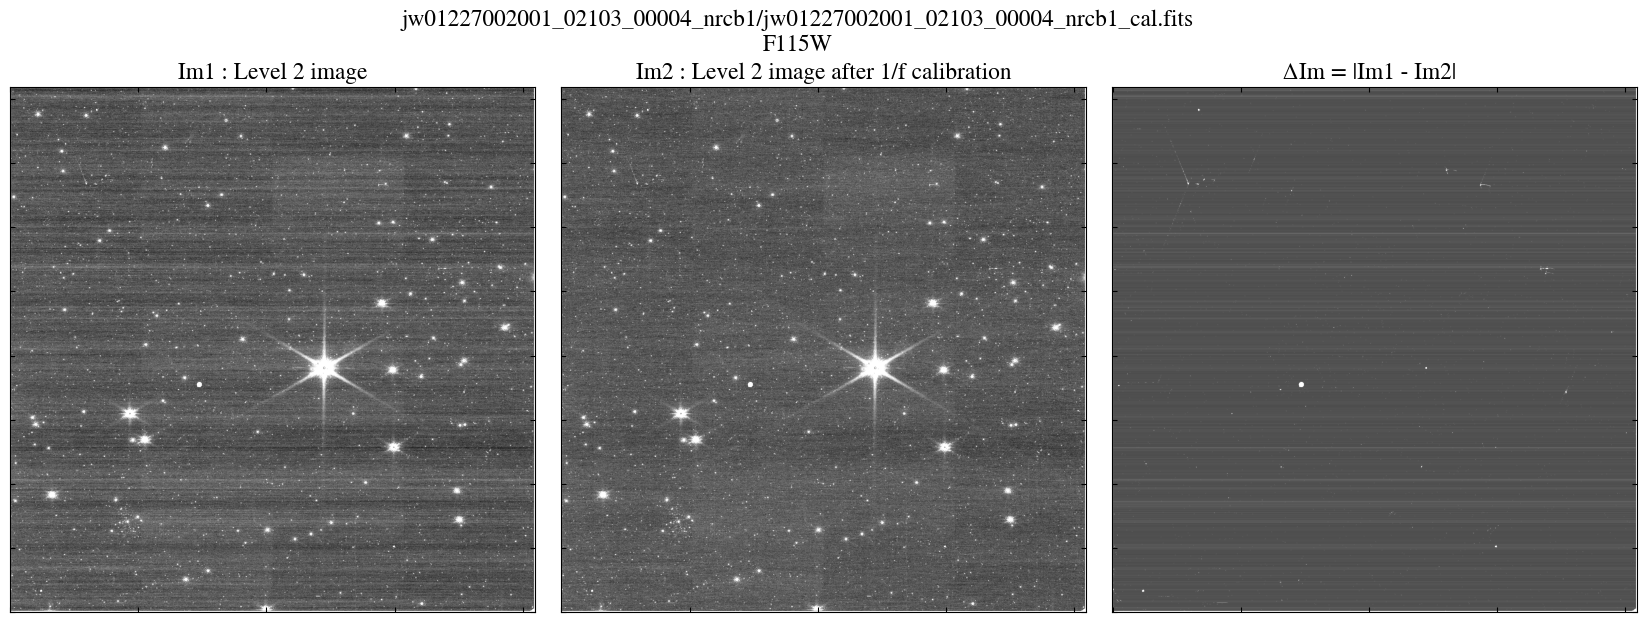

In [21]:
IMAGE_INDEX = 28
JWST_files.show_level2_and_one_over_f_difference(filename=JWST_files.cal_file_names[IMAGE_INDEX])

In [24]:
JWST_files.starbug2_aperture_photometry(filename                = JWST_files.cal_file_names[IMAGE_INDEX].replace('_cal.fits','_cal_1overf.fits'),
                                        remove_background       = True,
                                         sb2_param_path         = JWST_files._determine_filename_sb2_param(),
                                         overwrite_always_run   = False)


Skipping starbug2 run


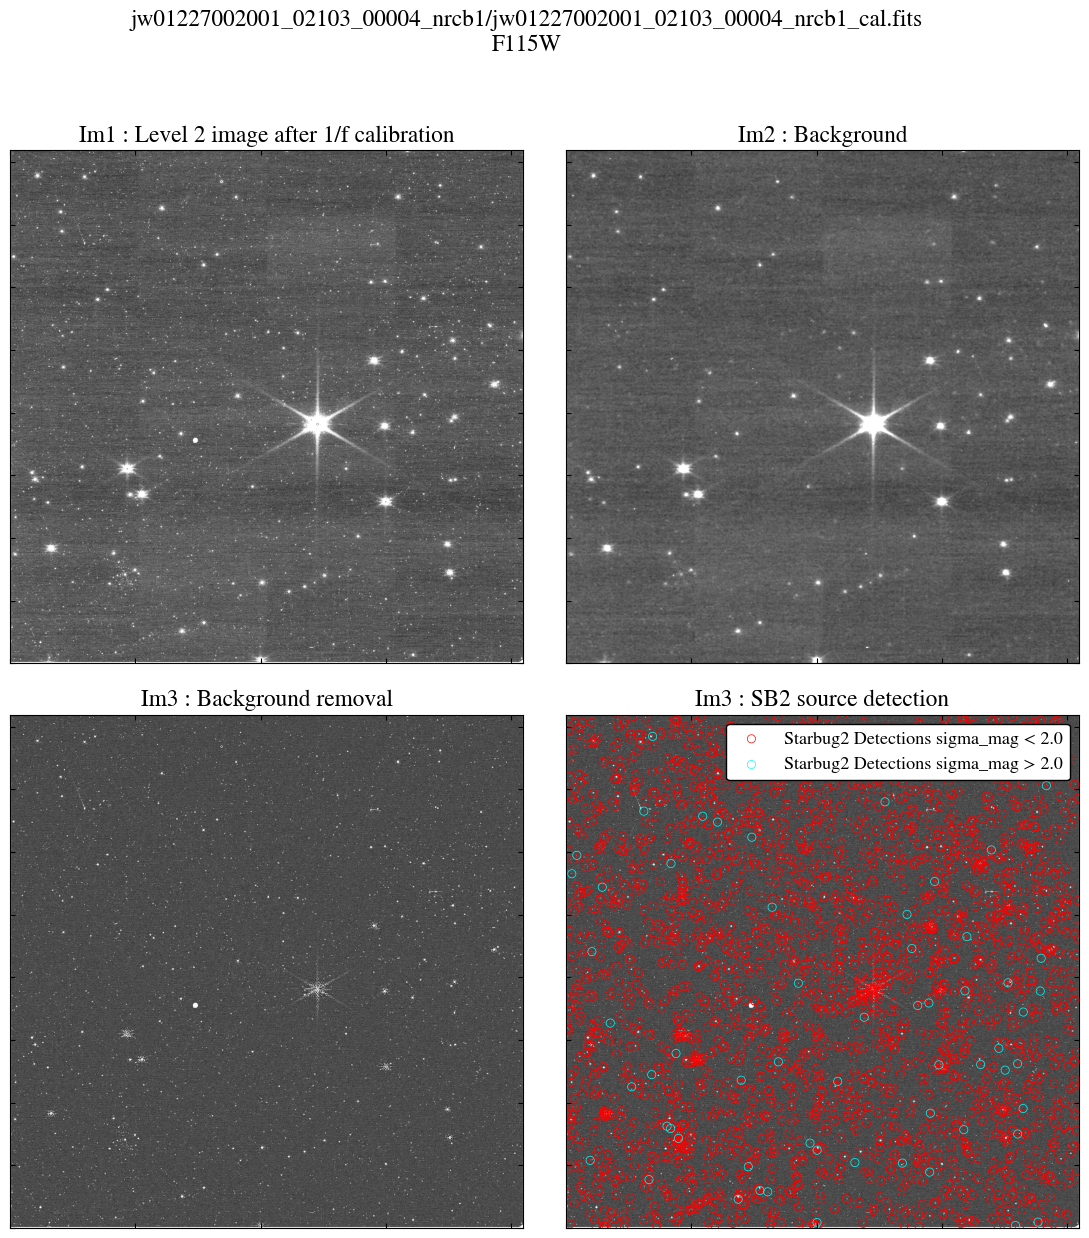

In [25]:
JWST_files.show_one_over_f_SB2( filename=JWST_files.cal_file_names[IMAGE_INDEX],
                                safefig_path = 'Plots/test/SB2_test_115w.pdf',
                                detection_sigma = 2.0)

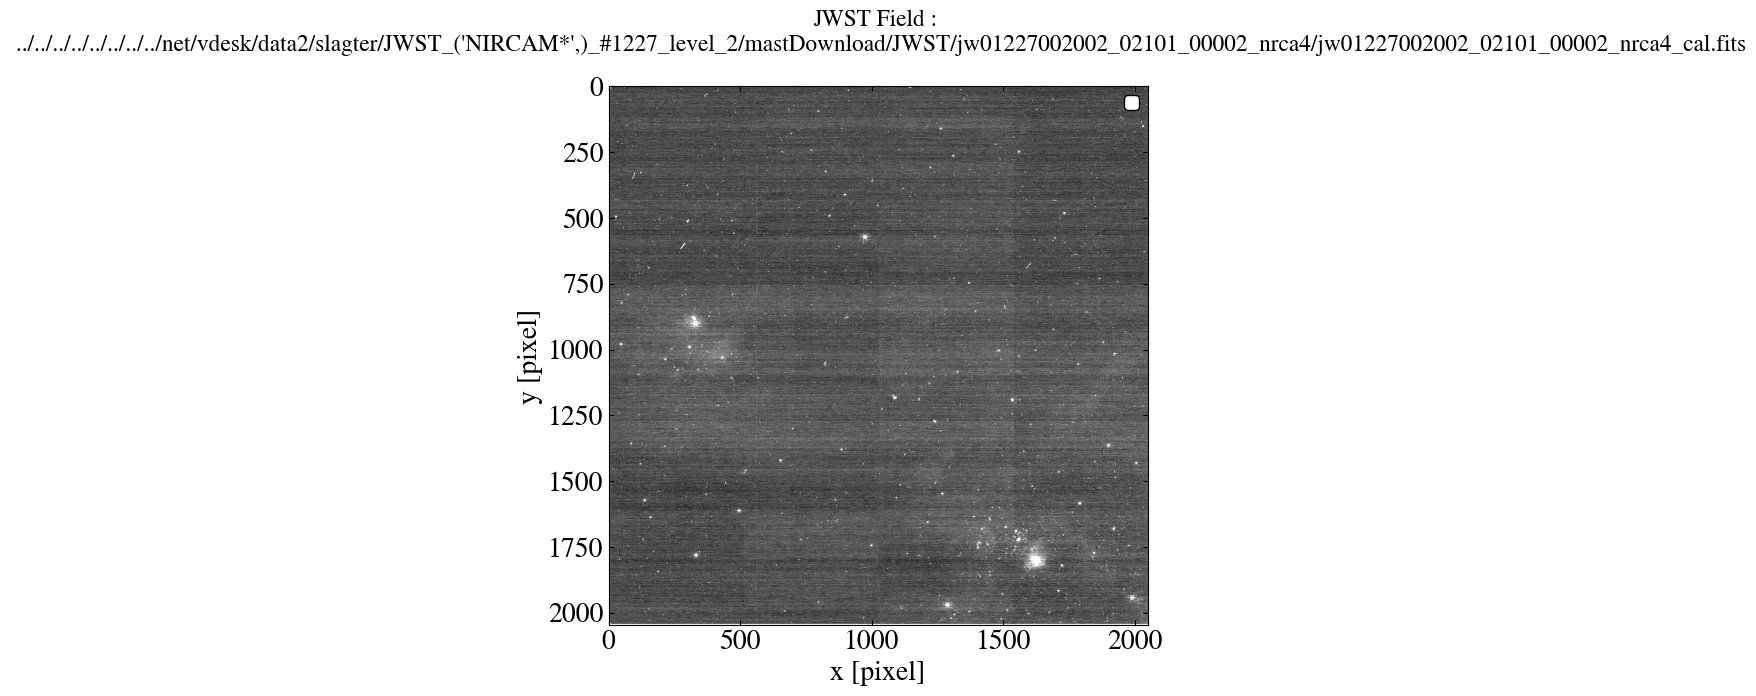

In [30]:
JWST_files.show_detections_over_field(file_index=28, show_detections=False)

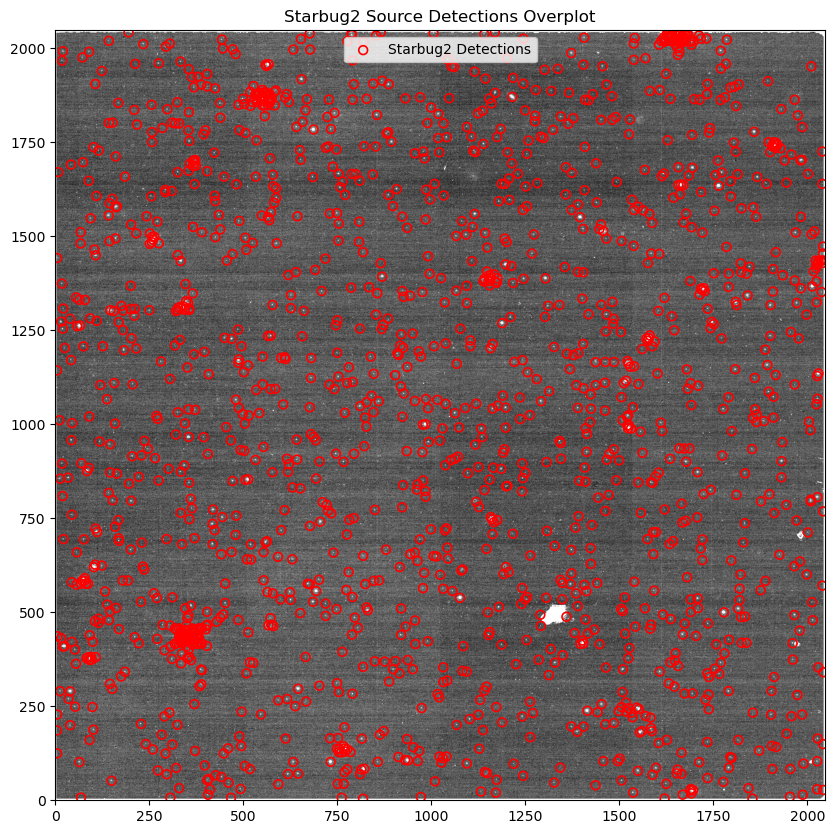

In [8]:
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(science_field)


plt.figure(figsize=(10, 10))
plt.imshow(science_field, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)

# 4. Overplot the source detections as open circles
plt.scatter(x_positions_sources, y_positions_sources, s=40, facecolors='none', edgecolors='red', linewidths=1.2, label='Starbug2 Detections')

plt.legend()
plt.title('Starbug2 Source Detections Overplot')
plt.show()